/home/sudharshan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4070" (12 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/sudharshan/.cache/warp/1.12.0
Nodes: 32  Edges: 31
Base restore: 1.272e-02  Tip restore: 7.952e-05
Stiffness ratio base/tip: 160×
Module __main__ ec8dbd9 load on device 'cuda:0' took 0.62 ms  (cached)


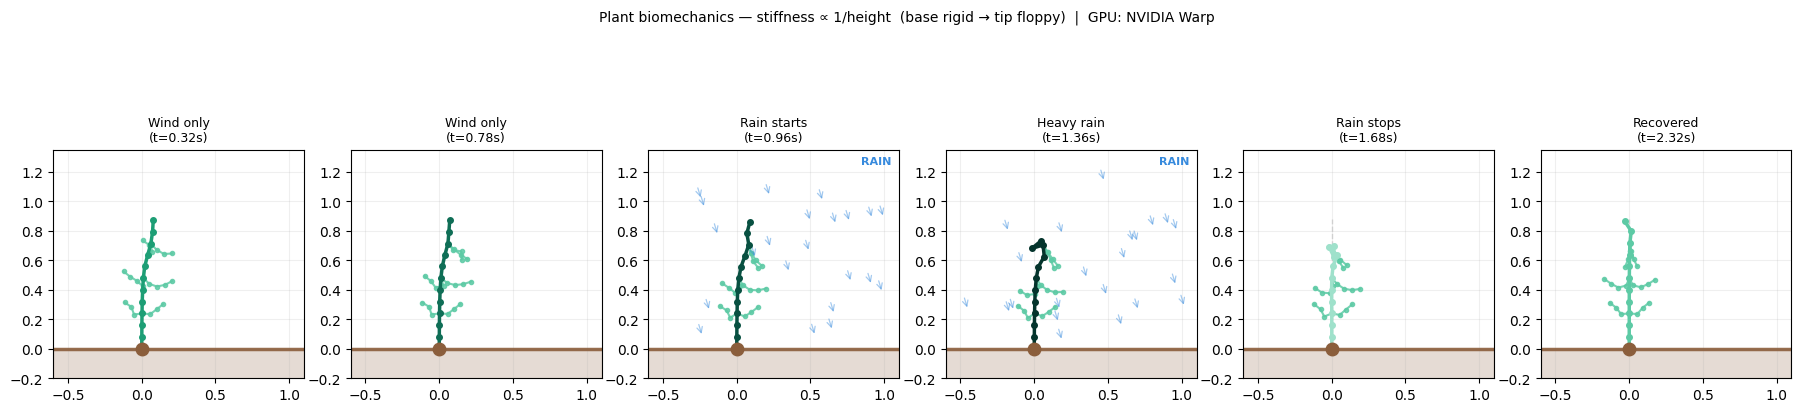

Saved plant_physics_accurate.png


In [4]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

STEM_NODES  = 12
L0_STEM     = 0.08
R_BASE      = 0.004
R_TIP       = 0.0015
E_STEM      = 200e6
LEAF_REST   = 0.055
R_LEAF      = 0.001
E_LEAF      = 50e6
SCALE_K     = 1e-5
SCALE_M     = 1e-3
G           = 9.8
DT          = 0.016
SUBSTEPS    = 4
RHO_STEM    = 800.0
RHO_LEAF    = 400.0
SOIL_DEPTH  = 0.15
LEAF_CONFIG = [
    (3,  50, 3), (3, -50, 3),
    (6,  55, 4), (6, -55, 4),
    (9,  45, 3), (9, -45, 3),
]

def height_stiffness_factor(i):
    t = i / (STEM_NODES - 1)
    return (1.0 - t) ** 3 * 0.97 + 0.03   # cubic — even sharper falloff

def stem_radius(i):
    t = i / (STEM_NODES - 1)
    return R_BASE + (R_TIP - R_BASE) * t

def area(r):           return np.pi * r**2
def second_moment(r):  return np.pi * r**4 / 4.0

def axial_spring_k(E, r, L0, node_i=0):
    return SCALE_K * E * area(r) / L0 * height_stiffness_factor(node_i)

def node_mass(rho, r, L0):
    return SCALE_M * rho * area(r) * L0


positions, is_root, is_leaf, edges, masses = [], [], [], [], []
restore_per_node = []

for i in range(STEM_NODES):
    positions.append([0.0, i * L0_STEM, 0.0])
    is_root.append(1 if i == 0 else 0)
    is_leaf.append(0)
    r = stem_radius(i)
    masses.append(node_mass(RHO_STEM, r, L0_STEM))
    # Restore: very weak at tip so wind/rain visibly push it
    restore_per_node.append(
        axial_spring_k(E_STEM, r, L0_STEM, node_i=i) * 0.015
    )
    if i > 0:
        edges.append((i - 1, i, L0_STEM,
                      axial_spring_k(E_STEM, r, L0_STEM, node_i=i), 0.0))

for (attach_node, angle_deg, n_leaf) in LEAF_CONFIG:
    angle_rad = np.radians(angle_deg)
    dx = np.sin(angle_rad) * LEAF_REST
    dy = np.cos(angle_rad) * LEAF_REST
    prev_idx = attach_node
    base_pos = positions[attach_node]
    leaf_factor = height_stiffness_factor(attach_node) * 0.3
    for j in range(1, n_leaf + 1):
        new_idx = len(positions)
        positions.append([base_pos[0] + dx*j, base_pos[1] + dy*j, 0.0])
        is_root.append(0); is_leaf.append(1)
        masses.append(node_mass(RHO_LEAF, R_LEAF, LEAF_REST))
        k_ax = SCALE_K * E_LEAF * area(R_LEAF) / LEAF_REST * leaf_factor
        restore_per_node.append(k_ax * 0.005)   # leaves: nearly free
        edges.append((prev_idx, new_idx, LEAF_REST, k_ax, 0.0))
        prev_idx = new_idx

pos_np      = np.array(positions, dtype=np.float32)
vel_np      = np.zeros_like(pos_np)
root_np     = np.array(is_root,  dtype=np.int32)
leaf_np     = np.array(is_leaf,  dtype=np.int32)
mass_np     = np.array(masses,   dtype=np.float32)
restore_np  = np.array(restore_per_node, dtype=np.float32)
rest_np     = pos_np.copy()
n_total     = len(positions)

k_axial_np  = np.array([e[3] for e in edges], dtype=np.float32)
parents_np  = np.array([e[0] for e in edges], dtype=np.int32)
children_np = np.array([e[1] for e in edges], dtype=np.int32)
L0_np       = np.array([e[2] for e in edges], dtype=np.float32)
n_edges     = len(edges)

print(f"Nodes: {n_total}  Edges: {n_edges}")
print(f"Base restore: {restore_np[1]:.3e}  Tip restore: {restore_np[STEM_NODES-1]:.3e}")
print(f"Stiffness ratio base/tip: {restore_np[1]/restore_np[STEM_NODES-1]:.0f}×")


@wp.kernel
def apply_physics(
    positions:    wp.array(dtype=wp.vec3),
    velocities:   wp.array(dtype=wp.vec3),
    rest_pos:     wp.array(dtype=wp.vec3),
    masses:       wp.array(dtype=wp.float32),
    restore_arr:  wp.array(dtype=wp.float32),
    is_root:      wp.array(dtype=wp.int32),
    is_leaf:      wp.array(dtype=wp.int32),
    parents:      wp.array(dtype=wp.int32),
    children:     wp.array(dtype=wp.int32),
    k_axial:      wp.array(dtype=wp.float32),
    L0_arr:       wp.array(dtype=wp.float32),
    n_edges:      int,
    soil_depth:   float,
    rain_on:      int,
    wind_strength: float,
    dt:           float
):
    i = wp.tid()
    if is_root[i] == 1:
        return

    m = masses[i]

    # Wind force scales with height — taller nodes feel more wind
    h_factor = positions[i][1] * 1.5 + 0.2
    wind = wp.vec3(wind_strength, 0.0, 0.0) * m * h_factor

    gravity = wp.vec3(0.0, -9.8 * m, 0.0)

    rain = wp.vec3(0.0, 0.0, 0.0)
    if rain_on == 1:
        if is_leaf[i] == 1:
            rain = wp.vec3(2.0, -8.0, 0.0) * m * h_factor
        else:
            rain = wp.vec3(3.0, -10.0, 0.0) * m * h_factor

    spring_force = wp.vec3(0.0, 0.0, 0.0)
    for e in range(n_edges):
        if children[e] == i:
            p_idx = parents[e]
            diff  = positions[p_idx] - positions[i]
            dist  = wp.length(diff)
            L0    = L0_arr[e]
            k     = k_axial[e]
            if dist > 1e-6:
                ext = dist - L0
                spring_force = spring_force + (diff / dist) * k * ext

    displacement  = rest_pos[i] - positions[i]
    restore_force = displacement * restore_arr[i]

    total_force = gravity + wind + rain + spring_force + restore_force
    accel       = total_force / m

    a_mag = wp.length(accel)
    a_max = float(150.0)
    if a_mag > a_max:
        accel = accel * (a_max / a_mag)

    damping = float(0.94)
    if positions[i][1] < soil_depth:
        damping = float(0.55)

    velocities[i] = (velocities[i] + accel * dt) * damping

    v_mag = wp.length(velocities[i])
    v_max = float(12.0)
    if v_mag > v_max:
        velocities[i] = velocities[i] * (v_max / v_mag)

    positions[i] = positions[i] + velocities[i] * dt


def enforce_constraints_cpu(pos_np, vel_np):
    # SINGLE pass, gentle correction — preserves bending
    for (parent_idx, child_idx, L0, k_ax, k_bn) in edges:
        diff = pos_np[child_idx] - pos_np[parent_idx]
        dist = np.linalg.norm(diff)
        if dist > 1e-6:
            correction = diff * (1.0 - L0 / dist)
            pos_np[child_idx] -= correction * 0.3   # gentler
    for i in range(n_total):
        if pos_np[i][1] < 0.0:
            pos_np[i][1] = 0.0
            vel_np[i][1] = 0.0
    return pos_np, vel_np


SAVE_AT = [
    (20,  "Wind only\n(t=0.32s)",   False, 8.0),
    (49,  "Wind only\n(t=0.78s)",   False, 8.0),
    (60,  "Rain starts\n(t=0.96s)", True,  6.0),
    (85,  "Heavy rain\n(t=1.36s)",  True,  6.0),
    (105, "Rain stops\n(t=1.68s)",  False, 2.0),
    (145, "Recovered\n(t=2.32s)",   False, 0.5),
]
save_frames = {s[0] for s in SAVE_AT}
saved = {}

sub_dt = DT / SUBSTEPS

for frame in range(150):
    rain_active = 1 if 50 <= frame < 100 else 0

    # Wind ramps: strong steady wind, then drops after rain ends
    if frame < 50:        wind_str = 8.0
    elif frame < 100:     wind_str = 6.0
    elif frame < 120:     wind_str = 2.0
    else:                 wind_str = 0.5

    for _ in range(SUBSTEPS):
        pos_gpu  = wp.array(pos_np,    dtype=wp.vec3,    device="cuda")
        vel_gpu  = wp.array(vel_np,    dtype=wp.vec3,    device="cuda")
        rest_gpu = wp.array(rest_np,   dtype=wp.vec3,    device="cuda")
        mass_gpu = wp.array(mass_np,   dtype=wp.float32, device="cuda")
        rk_gpu   = wp.array(restore_np, dtype=wp.float32, device="cuda")
        root_gpu = wp.array(root_np,   dtype=wp.int32,   device="cuda")
        leaf_gpu = wp.array(leaf_np,   dtype=wp.int32,   device="cuda")
        par_gpu  = wp.array(parents_np,  dtype=wp.int32,   device="cuda")
        chi_gpu  = wp.array(children_np, dtype=wp.int32,   device="cuda")
        kax_gpu  = wp.array(k_axial_np,  dtype=wp.float32, device="cuda")
        L0_gpu   = wp.array(L0_np,       dtype=wp.float32, device="cuda")

        wp.launch(apply_physics, dim=n_total,
                  inputs=[pos_gpu, vel_gpu, rest_gpu, mass_gpu, rk_gpu,
                          root_gpu, leaf_gpu,
                          par_gpu, chi_gpu, kax_gpu, L0_gpu,
                          n_edges, SOIL_DEPTH, rain_active,
                          wind_str, sub_dt])

        pos_np = pos_gpu.numpy().copy()
        vel_np = vel_gpu.numpy().copy()

        if not np.all(np.isfinite(pos_np)):
            pos_np = rest_np.copy()
            vel_np = np.zeros_like(pos_np)

        pos_np[0] = [0.0, 0.0, 0.0]
        vel_np[0] = [0.0, 0.0, 0.0]
        pos_np, vel_np = enforce_constraints_cpu(pos_np, vel_np)

    if frame in save_frames:
        saved[frame] = pos_np.copy()


fig, axes = plt.subplots(1, 6, figsize=(18, 5))
stem_palette = ['#1D9E75','#0F6E56','#085041','#04342C','#9FE1CB','#5DCAA5']
leaf_color   = '#5DCAA5'
rain_col     = '#378ADD'

for col_idx, (frame_num, label, rain_flag, _) in enumerate(SAVE_AT):
    ax        = axes[col_idx]
    frame_pos = saved[frame_num]

    ax.set_xlim(-0.6, 1.1)
    ax.set_ylim(-0.2, 1.35)
    ax.set_autoscale_on(False)

    ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.22)
    ax.axhline(y=0, color='#8B5E3C', linewidth=2.5, alpha=0.9)

    if rain_flag:
        rng = np.random.default_rng(seed=col_idx * 7)
        for _ in range(22):
            rx = rng.uniform(-0.5, 1.0)
            ry = rng.uniform(0.15, 1.25)
            ax.annotate('', xy=(rx+0.03, ry-0.10), xytext=(rx, ry),
                        arrowprops=dict(arrowstyle='->',
                                        color=rain_col, lw=0.9, alpha=0.45))
        ax.text(0.97, 0.97, 'RAIN', transform=ax.transAxes,
                fontsize=8, color=rain_col, ha='right', va='top',
                fontweight='bold')

    if col_idx >= 4:
        ax.plot(rest_np[:STEM_NODES, 0], rest_np[:STEM_NODES, 1],
                '--', color='gray', linewidth=1.0, alpha=0.3, zorder=1)

    ax.plot(frame_pos[:STEM_NODES, 0], frame_pos[:STEM_NODES, 1],
            'o-', color=stem_palette[col_idx % len(stem_palette)],
            linewidth=2.5, markersize=4, zorder=3)

    node_cursor = STEM_NODES
    for (attach_node, angle_deg, n_leaf) in LEAF_CONFIG:
        leaf_idx = [attach_node] + list(range(node_cursor, node_cursor + n_leaf))
        ax.plot(frame_pos[leaf_idx, 0], frame_pos[leaf_idx, 1],
                'o-', color=leaf_color, linewidth=1.5,
                markersize=3, alpha=0.85, zorder=2)
        node_cursor += n_leaf

    ax.plot(0, 0, 'o', color='#8B5E3C', markersize=9, zorder=5)
    ax.set_title(label, fontsize=9)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)

plt.suptitle(
    "Plant biomechanics — stiffness ∝ 1/height  (base rigid → tip floppy)  |  GPU: NVIDIA Warp",
    fontsize=10
)
plt.tight_layout()
plt.savefig('plant_physics_accurate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plant_physics_accurate.png")